### Exploration of row reduction using zone map

In [ ]:
import csv
import time
import argparse
from tqdm import tqdm
from column_store import ResalePriceData
from column_store_encoded import ResalePriceDataEncoded
from column_store_zone_map import ResalePriceDataZoneMapCat
from column_store_combined import ResalePriceDataCombined

In [ ]:
town_map = {
    0: "BEDOK",
    1: "BUKIT PANJANG",
    2: "CLEMENTI",
    3: "CHOA CHU KANG",
    4: "HOUGANG",
    5: "JURONG WEST",
    6: "PASIR RIS",
    7: "TAMPINES",
    8: "WOODLANDS",
    9: "YISHUN",
}

year_map = {
    0: 2020,
    1: 2021,
    2: 2022,
    3: 2023,
    4: 2014,
    5: 2015,
    6: 2016,
    7: 2017,
    8: 2018,
    9: 2019,
}


def read_csv(file_path: str, type: int):
    if type == 0:
        resale_data = ResalePriceData()
    elif type == 1:
        resale_data = ResalePriceDataEncoded()
    elif type == 2:
        resale_data = ResalePriceDataZoneMapCat()
    elif type == 3:
        resale_data = ResalePriceDataCombined()
        
    with open(file_path, mode="r") as file:
        csv_reader = csv.reader(file)
        _ = next(csv_reader)
        for row in csv_reader:
            resale_data.add_data(row)
            # resale_data.add_data(
            #     month=row[0],
            #     town=row[1],
            #     flat_type=row[2],
            #     block=row[3],
            #     street_name=row[4],
            #     storey_range=row[5],
            #     floor_area_sqm=float(row[6]),
            #     flat_model=row[7],
            #     lease_commence_date=int(row[8]),
            #     resale_price=float(row[9]),
            # )
    return resale_data


In [5]:
# matric number
matric_number = "U2121223J"

last_digit_year = int(matric_number[-2])
year = year_map[last_digit_year]
month = int(matric_number[-3])
town_index = int(matric_number[-4])
town = town_map[town_index]

file_path = "ResalePricesSingapore.csv"
column_store = read_csv(file_path, 0)
column_store_encoded = read_csv(file_path, 1)
column_store_zone_map = read_csv(file_path, 2)
column_store_combined = read_csv(file_path, 3)

column_store_encoded.encode_town()

column_store_zone_map.create_zone_map("flat_type")

column_store_combined.create_zone_map("flat_type") #have to zonemap first to create the rearrange columns, then encode town on that rearrange columns
column_store_combined.encode_town()

In [6]:
_,cs_min_price_logs = column_store.min_price(year,month,town,log_query=True)
_,cs_sd_price_logs = column_store.sd_price(year,month,town,log_query=True)
_,cs_avg_price_logs = column_store.avg_price(year,month,town,log_query=True)
_,cs_min_price_per_sqm_logs = column_store.min_price_per_sqm(year,month,town,log_query=True)

# -----------------

_,cs_encoded_min_price_logs = column_store_encoded.min_price(year,month,town,log_query=True)
_,cs_encoded_sd_price_logs = column_store_encoded.sd_price(year,month,town,log_query=True)
_,cs_encoded_avg_price_logs = column_store_encoded.avg_price(year,month,town,log_query=True)
_,cs_encoded_min_price_per_sqm_logs = column_store_encoded.min_price_per_sqm(year,month,town,log_query=True)

# ------------------

_,cs_zone_map_min_price_logs = column_store_zone_map.min_price(year,month,town,log_query=True)
_,cs_zone_map_sd_price_logs = column_store_zone_map.sd_price(year,month,town,log_query=True)
_,cs_zone_map_avg_price_logs = column_store_zone_map.avg_price(year,month,town,log_query=True)
_,cs_zone_map_min_price_per_sqm_logs = column_store_zone_map.min_price_per_sqm(year,month,town,log_query=True)

# ------------------
_,cs_combined_min_price_logs = column_store_combined.min_price(year,month,town,log_query=True)
_,cs_combined_sd_price_logs = column_store_combined.sd_price(year,month,town,log_query=True)
_,cs_combined_avg_price_logs = column_store_combined.avg_price(year,month,town,log_query=True)
_,cs_combined_min_price_per_sqm_logs = column_store_combined.min_price_per_sqm(year,month,town,log_query=True)


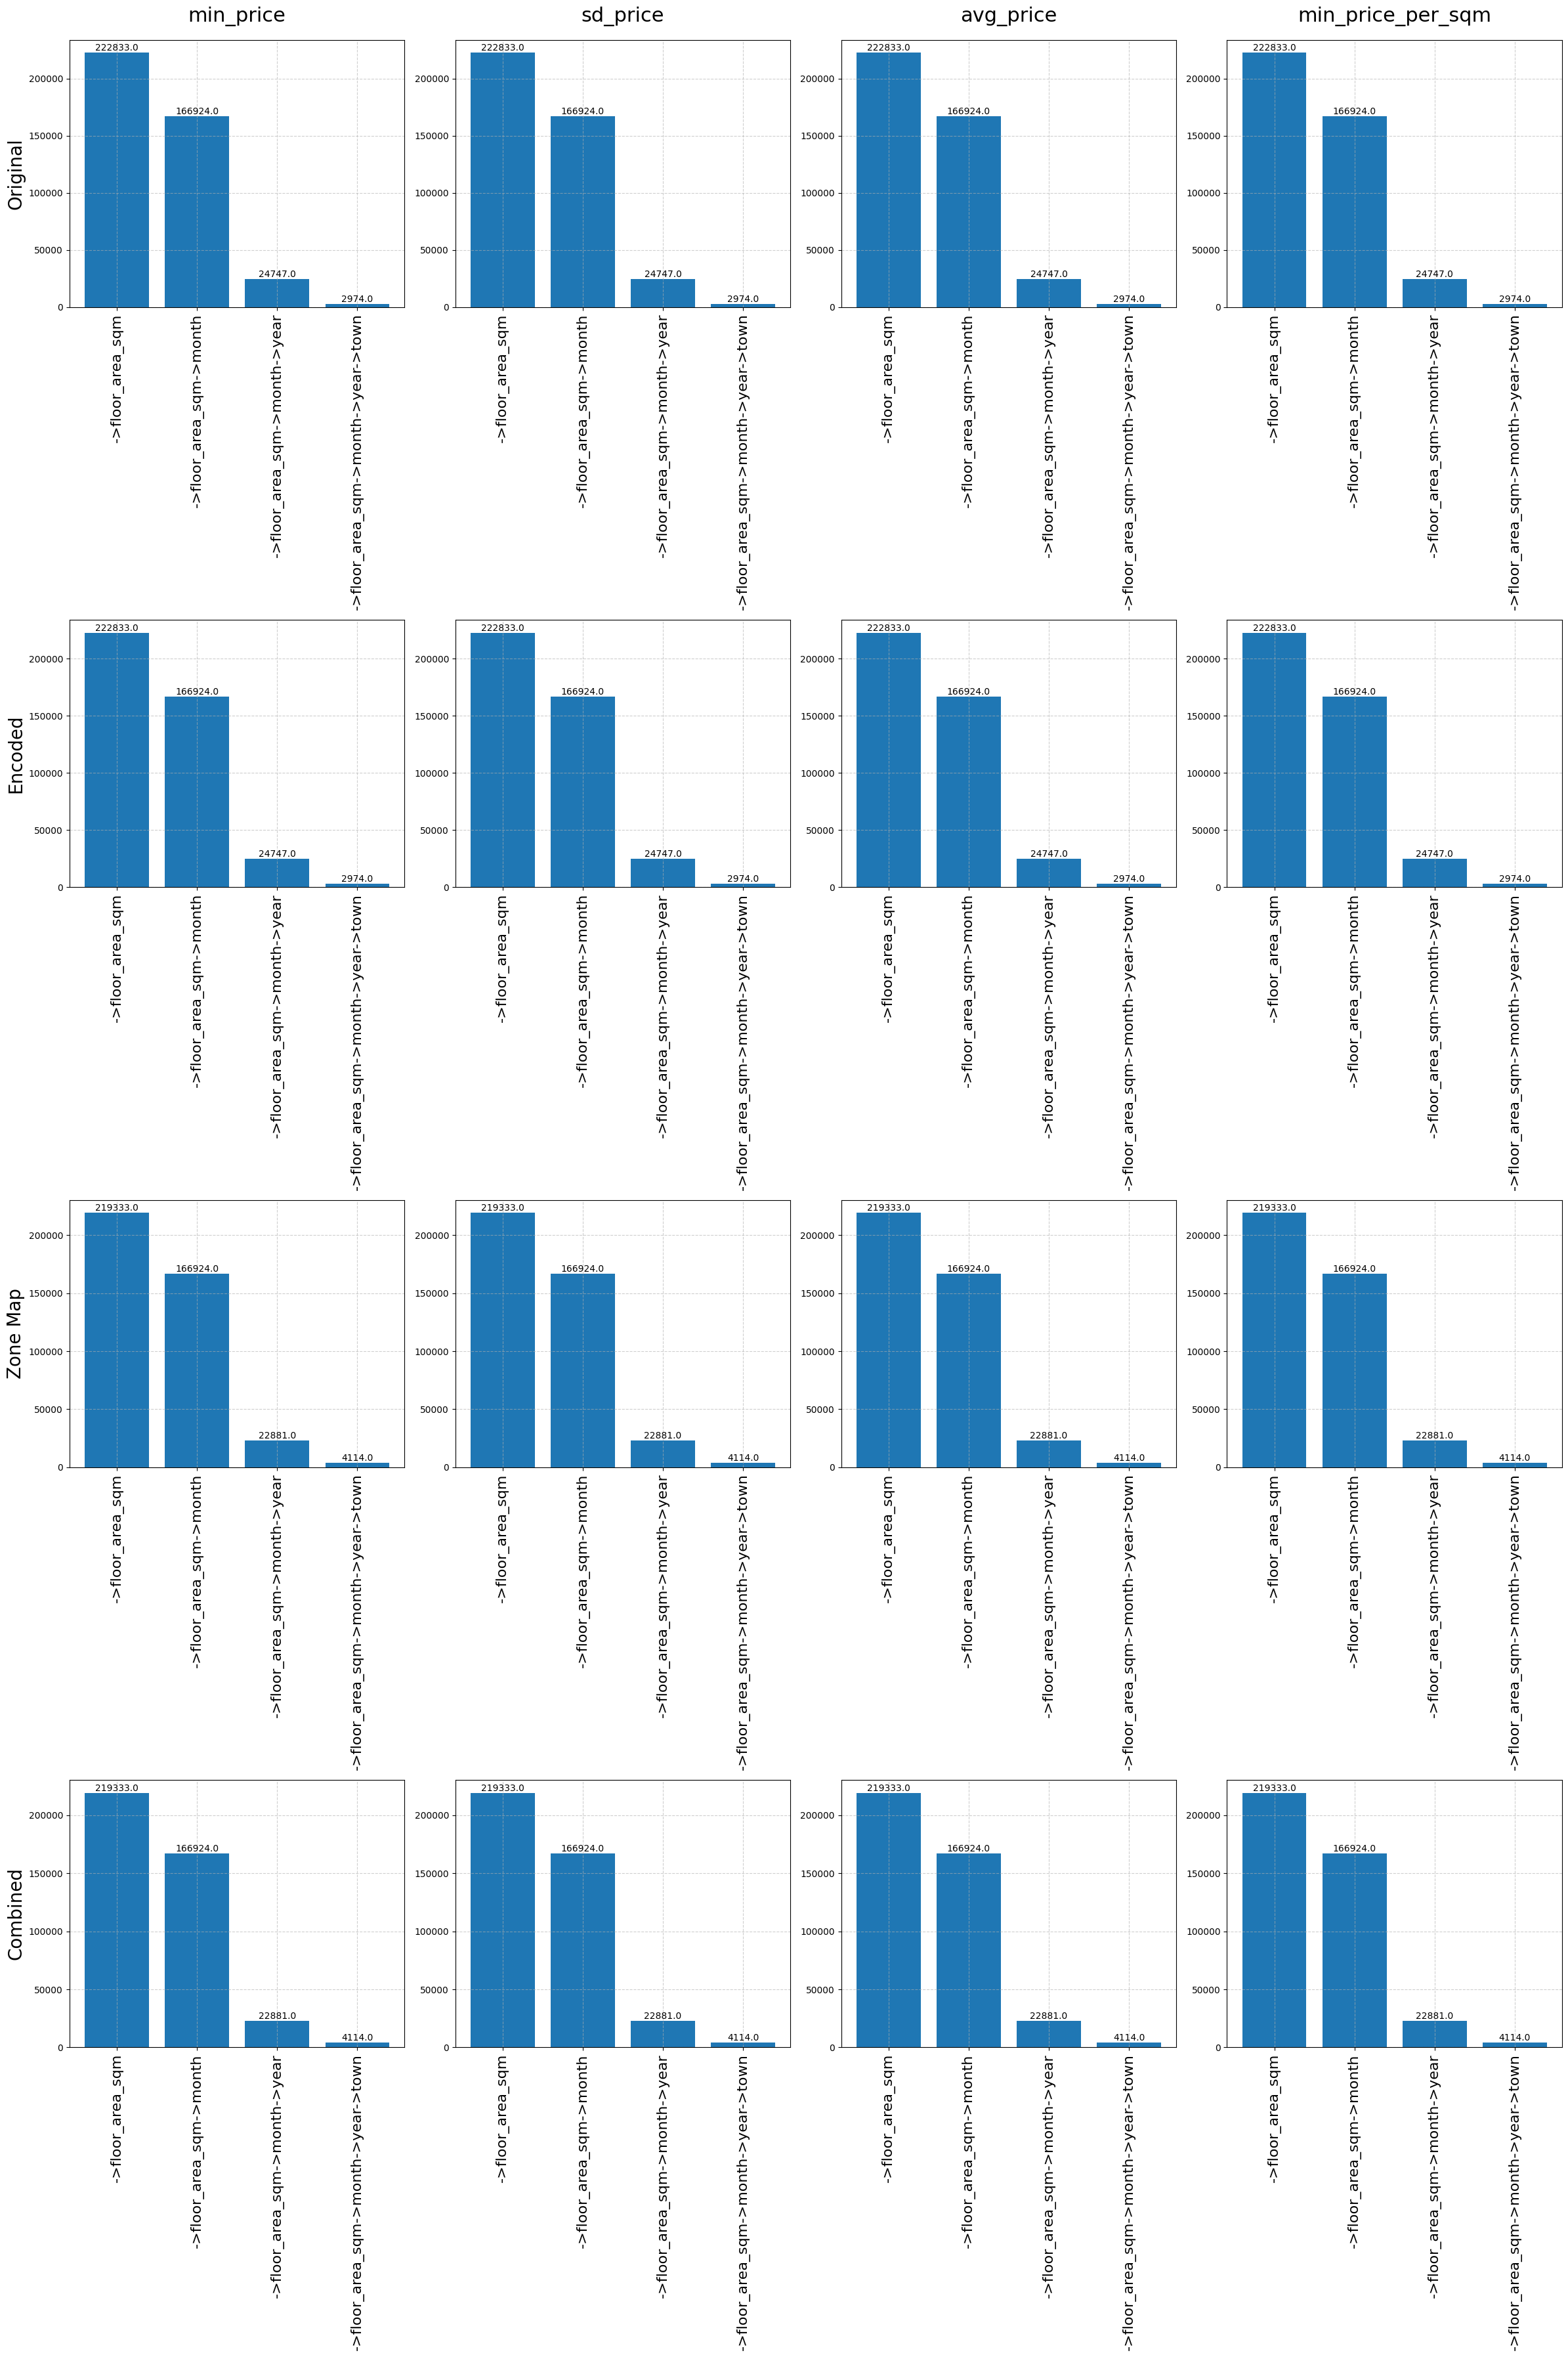

In [19]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(4, 4, figsize=(24, 36))

# Function to add labels on bars
def add_value_labels(ax):
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}', 
                ha='center', va='bottom', fontsize=10)

# Titles for each row
row_titles = ["Original", "Encoded", "Zone Map", "Combined"]
column_titles = ['min_price', 'sd_price', 'avg_price', 'min_price_per_sqm']
data_groups = [
    [cs_min_price_logs, cs_sd_price_logs, cs_avg_price_logs, cs_min_price_per_sqm_logs],
    [cs_encoded_min_price_logs, cs_encoded_sd_price_logs, cs_encoded_avg_price_logs, cs_encoded_min_price_per_sqm_logs],
    [cs_zone_map_min_price_logs, cs_zone_map_sd_price_logs, cs_zone_map_avg_price_logs, cs_zone_map_min_price_per_sqm_logs],
    [cs_combined_min_price_logs, cs_combined_sd_price_logs, cs_combined_avg_price_logs, cs_combined_min_price_per_sqm_logs]
]

# Add column titles at the top
for j, col_title in enumerate(column_titles):
    axs[0][j].set_title(col_title, fontsize=22, pad=20)  # Add padding for better spacing

# Populate the plots
for i, row_title in enumerate(row_titles):
    axs[i][0].set_ylabel(row_title, fontsize=20)  # Label each row on the left
    
    for j, data in enumerate(data_groups[i]):
        axs[i][j].bar(data['cols'], data['lengths'])
        axs[i][j].tick_params(axis='x', rotation=90, labelsize=16)  # Increase x-axis label size
        axs[i][j].grid(True, linestyle="--", alpha=0.6)  # Add grid for clarity
        add_value_labels(axs[i][j])  # Add value labels

plt.tight_layout()
plt.show()


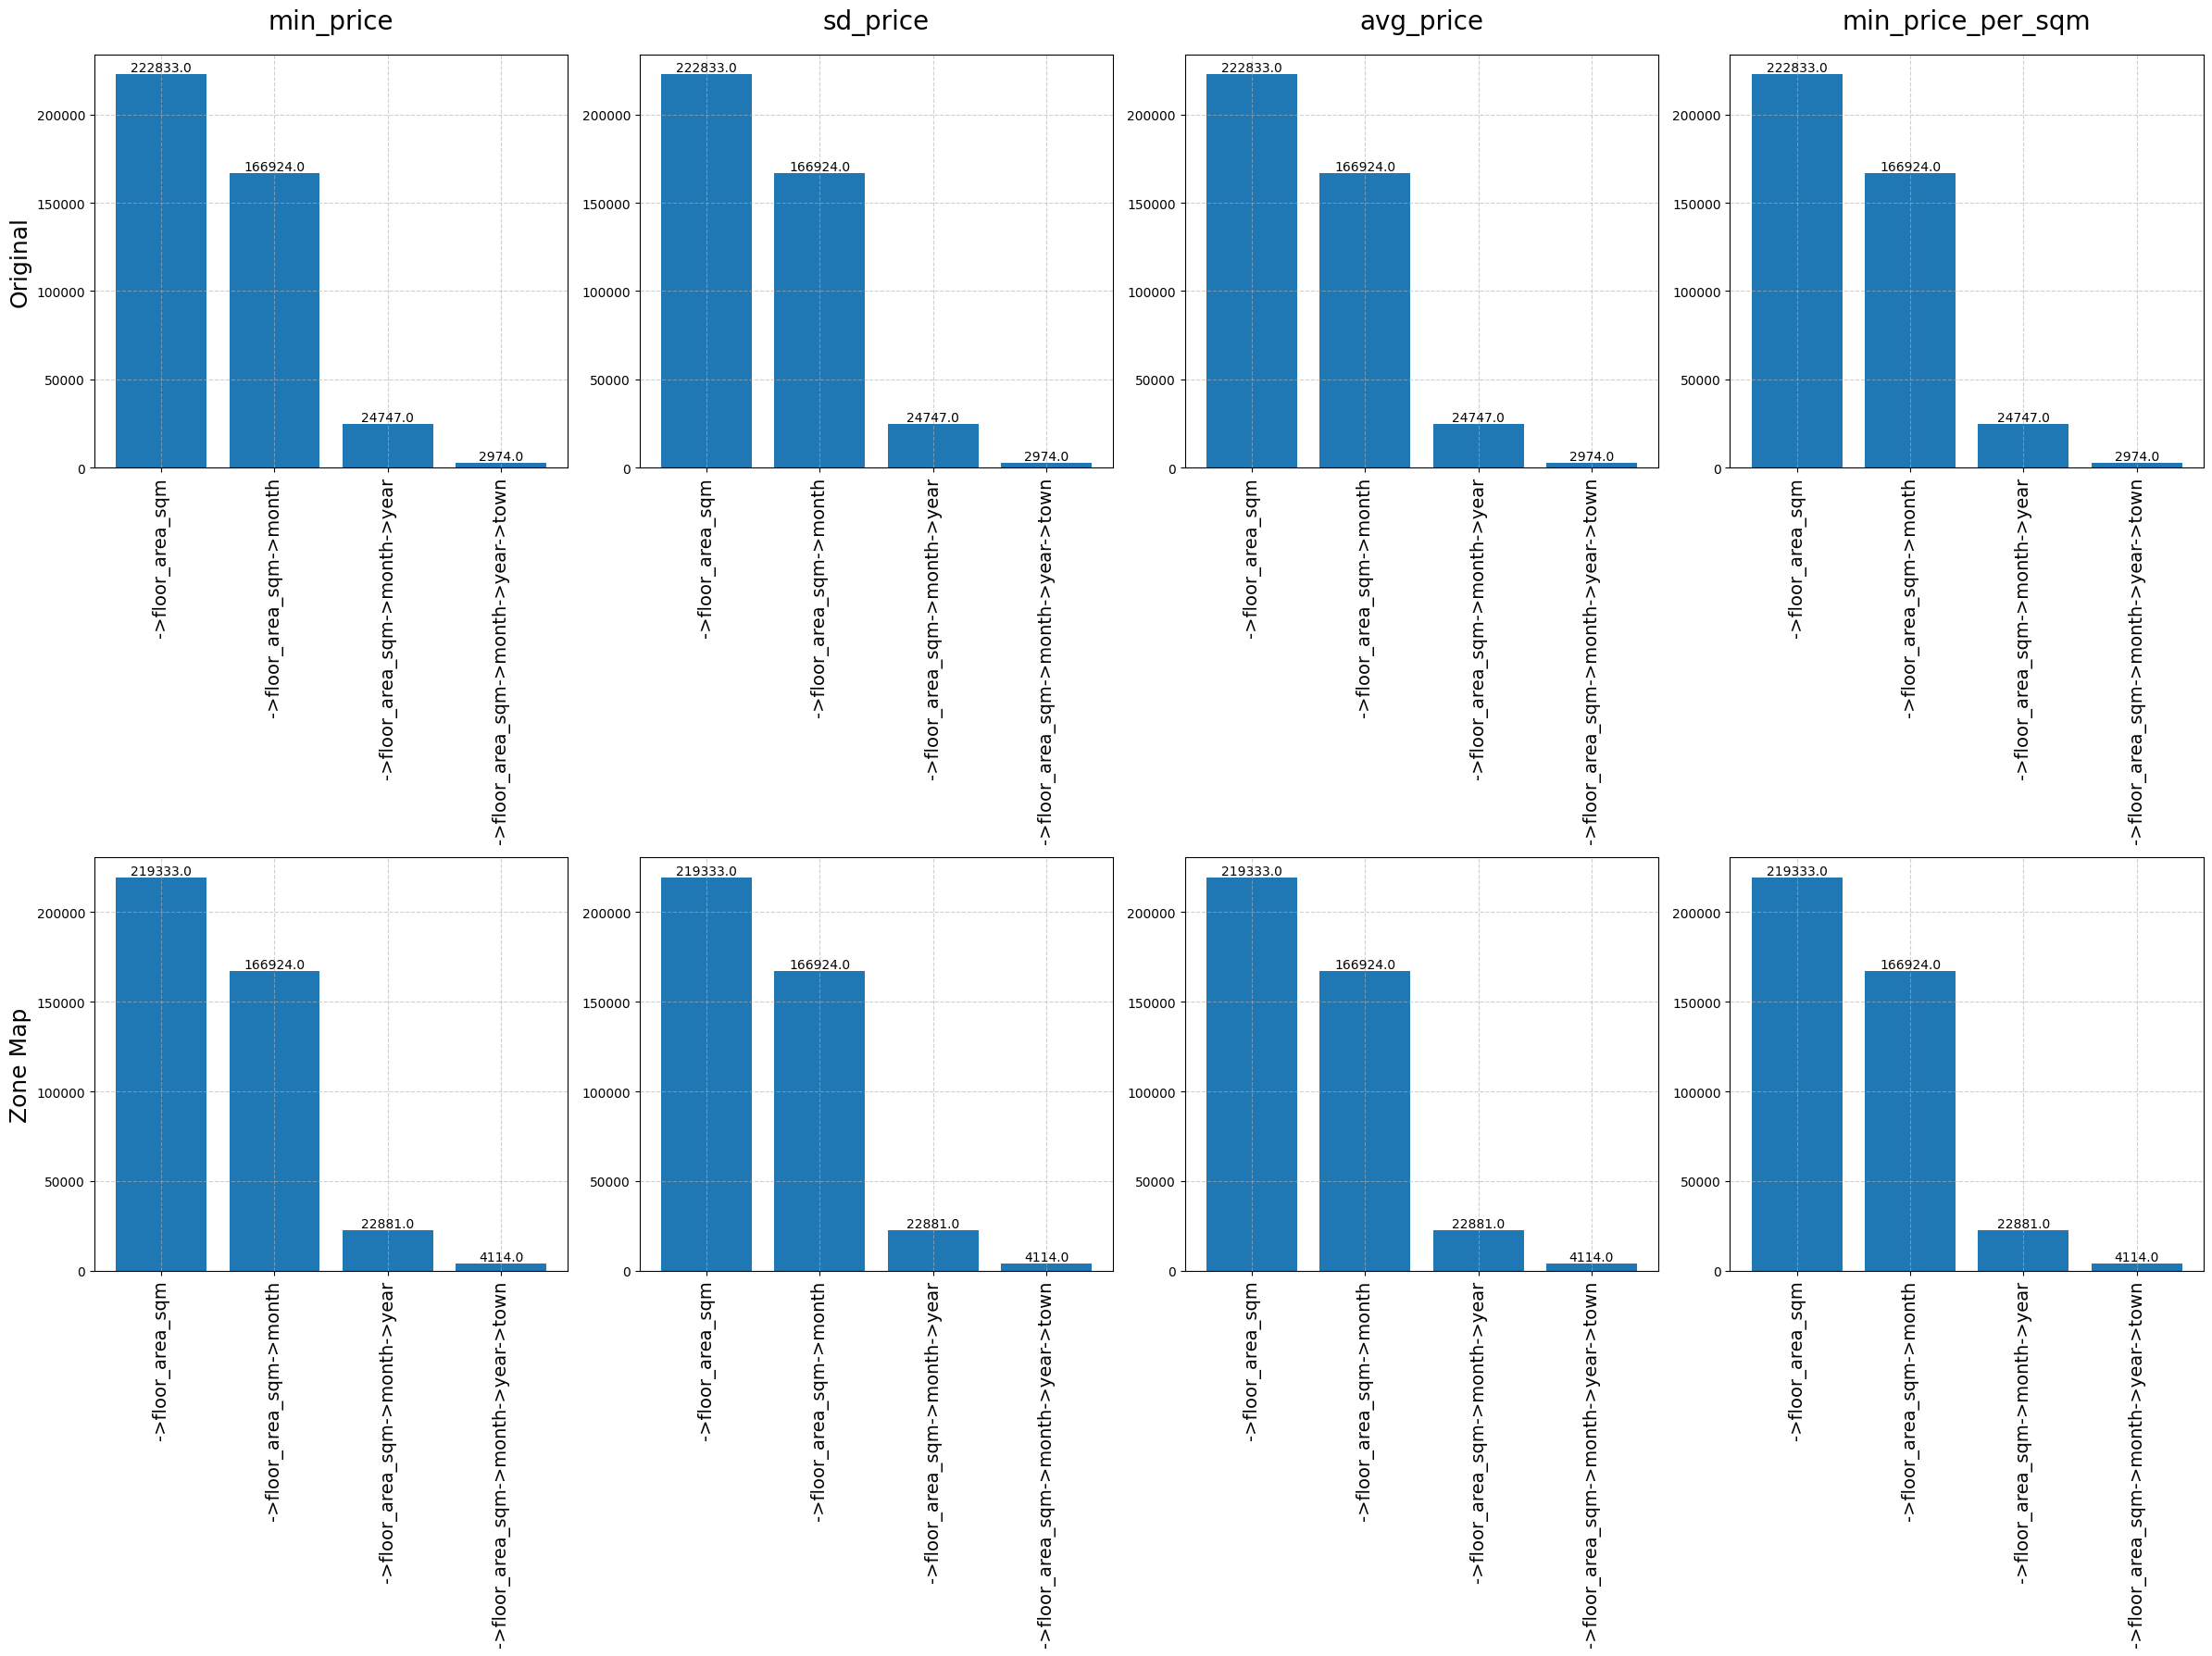

In [18]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 4, figsize=(24, 18))

# Function to add value labels on top of bars
def add_value_labels(ax):
    for bar in ax.patches:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, height, f'{height:.1f}', 
                ha='center', va='bottom', fontsize=10)

# Titles for each row
row_titles = ["Original", "Zone Map"]
column_titles = ['min_price', 'sd_price', 'avg_price', 'min_price_per_sqm']
data_groups = [
    [cs_min_price_logs, cs_sd_price_logs, cs_avg_price_logs, cs_min_price_per_sqm_logs],
    [cs_zone_map_min_price_logs, cs_zone_map_sd_price_logs, cs_zone_map_avg_price_logs, cs_zone_map_min_price_per_sqm_logs]
]

# Add column titles at the top
for j, col_title in enumerate(column_titles):
    axs[0][j].set_title(col_title, fontsize=20, pad=20)  # Increase padding for spacing

# Populate the plots
for i, row_title in enumerate(row_titles):
    axs[i][0].set_ylabel(row_title, fontsize=18)  # Label each row on the left
    
    for j, data in enumerate(data_groups[i]):
        axs[i][j].bar(data['cols'], data['lengths'])
        axs[i][j].tick_params(axis='x', rotation=90, labelsize=14)  # Increase font size
        axs[i][j].grid(True, linestyle="--", alpha=0.6)  # Add grid
        add_value_labels(axs[i][j])  # Add value labels

plt.tight_layout()
plt.show()